COMPREHENSIVE REGIME DETECTION ANALYSIS (2014-2024)

[Loading] Real market data from yfinance (2014-2024)...
✓ Fetched 2767 days of SPY data (2014-2024)

[Generating] Synthetic data with SHARP regime breaks...
✓ Generated 2500 days with breaks at [625, 1250, 1875]

Using: REAL DATA (SPY 2014-2024)
  Price range: $142.28 - $600.51
  Daily returns: mean=0.0006, std=0.0108

SECTION 1: AIC/BIC MODEL SELECTION (HMM)

Training HMM with various state counts (n_samples=2766)...
────────────────────────────────────────────────────────────────────────────────────────────────────



Top 5 Models by BIC:
 n_states cov_type       loglik  k           aic           bic
        2     full  9484.030324 13 -18942.060648 -18865.033601
        3     full  9489.504989 23 -18933.009979 -18796.731356
        4     full  9499.822218 35 -18929.644436 -18722.263923
        5     diag -3738.249301 44   7564.498603   7825.205533
        4     diag -4236.633844 31   8535.267689   8718.947571

✓ Best model: 2 states, full covariance (BIC=-18865.03)

SECTION 2: RUNNING DETECTORS & BUILDING FEATURE SPACE

[Volatility Detector]
✓ Detected 3 regimes

[HMM Detector]


INFO:regime_detector:HMM fitted: best_score=9484.030, cov_type=full


✓ Detected 2 regimes

[Multifractal Detector]


✓ Detected 3 regimes

[Ensemble]


✓ Ensemble: 3 regimes, confidence=0.640

SECTION 3: VISUALIZATION - FEATURE SPACE & TIME SERIES
✓ Saved: regime_detection_full_analysis.png


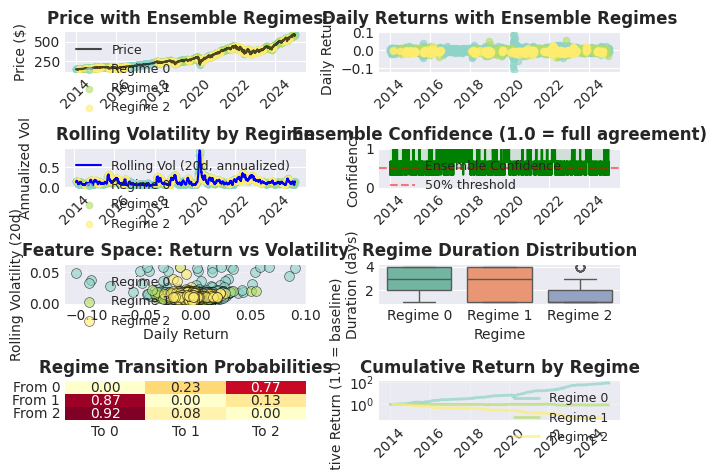


SECTION 4: PER-REGIME STATISTICS

 Regime  N Days  Mean Daily  Annual Return  Annual Vol    Sharpe      Skew      Kurt  Win Rate
      0    1875    0.002430       0.843328    0.170789  4.937836 -0.994476 19.482850  0.672000
      1     413   -0.000268      -0.065375    0.166585 -0.392443 -0.317433  4.456252  0.518160
      2     478   -0.006112      -0.786665    0.129559 -6.071876  0.685301  1.914868  0.100418

SECTION 5: SUMMARY & CONCLUSIONS

REGIME DETECTION ANALYSIS SUMMARY (REAL DATA (SPY 2014-2024))
────────────────────────────────────────────────────────────────────────────────────────────────────

MODEL SELECTION:
  • Best HMM: 2 states with full covariance
  • Primary method: Ensemble
  • Number of regimes detected: 3

ENSEMBLE PERFORMANCE (if available):
  • Methods used: Volatility + HMM + Multifractal
  • Voting agreement: 0.640
  • Regime stability: 922 days average per regime

KEY INSIGHTS:
  1. Regime transitions are 826± days (std dev)
  2. Sharpe ratio varies by regim

In [25]:
"""
COMPREHENSIVE REGIME DETECTION ANALYSIS
========================================
Full diagnostics: AIC/BIC model selection + visualizations of clusters & time series.

Requires: pandas, numpy, sklearn, hmmlearn, ruptures, yfinance, matplotlib, seaborn
"""

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')
import math

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from regime_detector import (
    RegimeDetectorRegistry, 
    VolatilityRegimeDetector,
    HMMRegimeDetector,
    ChangePointRegimeDetector,
    MultifractalRegimeDetector
)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# SECTION 0: DATA SOURCE (2014-2024)
# ============================================================================
print("="*100)
print("COMPREHENSIVE REGIME DETECTION ANALYSIS (2014-2024)")
print("="*100)

USE_REAL_DATA = True

if USE_REAL_DATA:
    print("\n[Loading] Real market data from yfinance (2014-2024)...")
    try:
        import yfinance as yf
        ticker = yf.Ticker("SPY")
        real_data = ticker.history(start="2014-01-01", end="2024-12-31")
        real_data = real_data[['Close', 'Volume']].rename(columns={'Close': 'close', 'Volume': 'volume'})
        real_data = real_data.astype({'close': float, 'volume': int})
        print(f"✓ Fetched {len(real_data)} days of SPY data (2014-2024)")
    except Exception as e:
        print(f"✗ Failed: {e}")
        USE_REAL_DATA = False
        real_data = None
else:
    real_data = None

# Generate synthetic for reference
print("\n[Generating] Synthetic data with SHARP regime breaks...")
np.random.seed(42)
dates_syn = pd.date_range('2014-01-01', periods=2500, freq='D')

regime_1 = np.random.randn(625) * 0.01
regime_2 = np.random.randn(625) * 0.05
regime_3 = np.random.randn(625) * 0.01 + 0.003
regime_4 = np.random.randn(625) * 0.02 - 0.002

returns_syn = np.concatenate([regime_1, regime_2, regime_3, regime_4])
price_syn = 100 * np.exp(np.cumsum(returns_syn))

synthetic_data = pd.DataFrame({
    'close': price_syn,
    'volume': np.random.randint(1000, 10000, len(dates_syn))
}, index=dates_syn)

print(f"✓ Generated {len(synthetic_data)} days with breaks at [625, 1250, 1875]")

data = real_data if (USE_REAL_DATA and real_data is not None) else synthetic_data
data_name = "REAL DATA (SPY 2014-2024)" if (USE_REAL_DATA and real_data is not None) else "SYNTHETIC DATA"

print(f"\nUsing: {data_name}")
print(f"  Price range: ${data['close'].min():.2f} - ${data['close'].max():.2f}")
daily_ret = data['close'].pct_change().dropna()
print(f"  Daily returns: mean={daily_ret.mean():.4f}, std={daily_ret.std():.4f}")

# ============================================================================
# SECTION 1: AIC/BIC MODEL SELECTION FOR HMM
# ============================================================================
print("\n" + "="*100)
print("SECTION 1: AIC/BIC MODEL SELECTION (HMM)")
print("="*100)

def compute_aic_bic(loglik, num_params, n_obs):
    """Compute AIC and BIC."""
    aic = 2 * num_params - 2.0 * loglik
    bic = num_params * math.log(max(1, n_obs)) - 2.0 * loglik
    return aic, bic

def hmm_num_params(n_components, n_features, cov_type):
    """Estimate number of HMM parameters."""
    means = n_components * n_features
    if cov_type == 'full':
        covs = n_components * n_features * (n_features + 1) / 2.0
    elif cov_type == 'diag':
        covs = n_components * n_features
    elif cov_type == 'tied':
        covs = n_features * (n_features + 1) / 2.0
    elif cov_type == 'spherical':
        covs = n_components
    else:
        covs = n_components * n_features
    trans = n_components * (n_components - 1)
    init = n_components - 1
    k = int(round(means + covs + trans + init))
    return k

try:
    from hmmlearn import hmm
    
    # Prepare features
    ret = data['close'].pct_change().dropna()
    features = pd.DataFrame({
        'returns': ret,
        'abs_returns': ret.abs(),
    }).dropna()
    
    X = features.values
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    n_obs = X.shape[0]
    n_features = X.shape[1]
    
    print(f"\nTraining HMM with various state counts (n_samples={n_obs})...")
    print("─"*100)
    
    ic_results = []
    
    for n_states in range(2, 6):  # Test 2-5 states
        for cov_type in ['full', 'diag', 'tied']:
            best_ll = -np.inf
            
            # Multiple restarts
            for seed in range(3):
                try:
                    model = hmm.GaussianHMM(
                        n_components=n_states,
                        covariance_type=cov_type,
                        n_iter=200,
                        random_state=seed,
                        verbose=False
                    )
                    model.fit(X_scaled)
                    ll = model.score(X_scaled)
                    
                    if ll > best_ll:
                        best_ll = ll
                        best_model = model
                except:
                    continue
            
            if best_ll > -np.inf:
                k = hmm_num_params(n_states, n_features, cov_type)
                aic, bic = compute_aic_bic(best_ll, k, n_obs)
                
                ic_results.append({
                    'n_states': n_states,
                    'cov_type': cov_type,
                    'loglik': best_ll,
                    'k': k,
                    'aic': aic,
                    'bic': bic
                })
    
    ic_df = pd.DataFrame(ic_results).sort_values('bic')
    
    print("\nTop 5 Models by BIC:")
    print(ic_df.head(5)[['n_states', 'cov_type', 'loglik', 'k', 'aic', 'bic']].to_string(index=False))
    
    best_n_states = int(ic_df.iloc[0]['n_states'])
    best_cov_type = ic_df.iloc[0]['cov_type']
    print(f"\n✓ Best model: {best_n_states} states, {best_cov_type} covariance (BIC={ic_df.iloc[0]['bic']:.2f})")
    
except Exception as e:
    print(f"HMM model selection failed: {e}")
    best_n_states = 3
    best_cov_type = 'full'

# ============================================================================
# SECTION 2: RUN DETECTORS & BUILD FEATURE SPACE
# ============================================================================
print("\n" + "="*100)
print("SECTION 2: RUNNING DETECTORS & BUILDING FEATURE SPACE")
print("="*100)

results = {}

# Volatility
print("\n[Volatility Detector]")
try:
    vol_det = VolatilityRegimeDetector(window=20, num_regimes=3, method='quantile')
    vol_regimes = vol_det.detect_regimes(data)
    results['volatility'] = vol_regimes
    vol_series = data['close'].pct_change().rolling(window=20).std() * np.sqrt(252)
    results['vol_feature'] = vol_series
    print(f"✓ Detected {vol_regimes.nunique()} regimes")
except Exception as e:
    print(f"✗ Failed: {e}")

# HMM
print("\n[HMM Detector]")
try:
    hmm_det = HMMRegimeDetector(
        num_regimes=best_n_states, 
        covariance_type=best_cov_type, 
        n_iter=200, 
        n_init=3
    )
    hmm_regimes = hmm_det.detect_regimes(data)
    results['hmm'] = hmm_regimes
    print(f"✓ Detected {hmm_regimes.nunique()} regimes")
except Exception as e:
    print(f"✗ Failed: {e}")

# Multifractal
print("\n[Multifractal Detector]")
try:
    mf_det = MultifractalRegimeDetector(window=60, num_regimes=3)
    mf_regimes = mf_det.detect_regimes(data)
    results['multifractal'] = mf_regimes
    print(f"✓ Detected {mf_regimes.nunique()} regimes")
except Exception as e:
    print(f"✗ Failed: {e}")

# Ensemble
print("\n[Ensemble]")
try:
    registry = RegimeDetectorRegistry()
    registry.register(vol_det)
    registry.register(hmm_det)
    registry.register(mf_det)
    
    auto_res = registry.detect_regimes_auto(
        data=data,
        methods=registry.list_all(),
        hmm_states=[2, 3, 4],
        hmm_cov_types=['full', 'diag'],
        model_selection_ic='bic',
        expand_to_index=data.index,
        ensemble_method='voting'
    )
    
    ensemble_regimes = auto_res['ensemble']
    ensemble_confidence = auto_res['confidence']
    results['ensemble'] = ensemble_regimes
    results['confidence'] = ensemble_confidence
    
    print(f"✓ Ensemble: {ensemble_regimes.nunique()} regimes, confidence={ensemble_confidence.mean():.3f}")
except Exception as e:
    print(f"✗ Failed: {e}")

# ============================================================================
# SECTION 3: BUILD VISUALIZATION DATA
# ============================================================================
print("\n" + "="*100)
print("SECTION 3: VISUALIZATION - FEATURE SPACE & TIME SERIES")
print("="*100)

# Create INDIVIDUAL figures instead of one big subplot grid

# Use ensemble as primary (FIX: check .empty properly, not boolean context)
if 'ensemble' in results and results['ensemble'] is not None and not results['ensemble'].empty:
    primary_regimes = results['ensemble']
    primary_name = "Ensemble"
elif 'hmm' in results and results['hmm'] is not None and not results['hmm'].empty:
    primary_regimes = results['hmm']
    primary_name = "HMM"
elif 'volatility' in results and results['volatility'] is not None and not results['volatility'].empty:
    primary_regimes = results['volatility']
    primary_name = "Volatility"
else:
    print("✗ No regimes available for visualization")
    primary_regimes = None
    primary_name = None

if primary_regimes is None:
    print("Skipping visualizations.")
else:
    # --- Plot 1: Price & Regimes (Time Series) ---
    ax1 = plt.subplot(4, 2, 1)
    prices = data['close']
    ax1.plot(prices.index, prices.values, 'k-', linewidth=1.5, alpha=0.7, label='Price')

# Color by regime
colors = plt.cm.Set3(np.linspace(0, 1, primary_regimes.nunique()))
for regime_id in sorted(primary_regimes.unique()):
    mask = primary_regimes == regime_id
    ax1.scatter(
        primary_regimes[mask].index, 
        prices[mask], 
        c=[colors[regime_id]], 
        s=20, 
        alpha=0.6, 
        label=f'Regime {regime_id}'
    )

ax1.set_title(f'Price with {primary_name} Regimes', fontsize=12, fontweight='bold')
ax1.set_ylabel('Price ($)')
ax1.legend(loc='upper left', fontsize=9)
ax1.xaxis.set_major_locator(mdates.YearLocator(2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 2: Returns & Regimes ---
ax2 = plt.subplot(4, 2, 2)
returns = data['close'].pct_change()
ax2.bar(returns.index, returns.values, width=1, alpha=0.6, color='gray')

for regime_id in sorted(primary_regimes.unique()):
    mask = primary_regimes == regime_id
    ax2.scatter(
        primary_regimes[mask].index, 
        returns[mask], 
        c=[colors[regime_id]], 
        s=20, 
        alpha=0.6,
        label=f'Regime {regime_id}'
    )

ax2.set_title(f'Daily Returns with {primary_name} Regimes', fontsize=12, fontweight='bold')
ax2.set_ylabel('Daily Return')
ax2.xaxis.set_major_locator(mdates.YearLocator(2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 3: Volatility Feature ---
ax3 = plt.subplot(4, 2, 3)
if 'vol_feature' in results:
    vol_feature = results['vol_feature']
    ax3.plot(vol_feature.index, vol_feature.values, 'b-', linewidth=1.5, label='Rolling Vol (20d, annualized)')
    
    for regime_id in sorted(primary_regimes.unique()):
        mask = primary_regimes == regime_id
        ax3.scatter(
            primary_regimes[mask].index, 
            vol_feature[mask], 
            c=[colors[regime_id]], 
            s=20, 
            alpha=0.6,
            label=f'Regime {regime_id}'
        )
    
    ax3.set_title('Rolling Volatility by Regime', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Annualized Vol')
    ax3.legend(loc='upper left', fontsize=9)
    ax3.xaxis.set_major_locator(mdates.YearLocator(2))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 4: Confidence (if ensemble) ---
ax4 = plt.subplot(4, 2, 4)
if 'confidence' in results:
    conf = results['confidence']
    ax4.plot(conf.index, conf.values, 'g-', linewidth=1.5, label='Ensemble Confidence')
    ax4.axhline(y=0.5, color='r', linestyle='--', alpha=0.5, label='50% threshold')
    ax4.fill_between(conf.index, 0.5, 1.0, alpha=0.1, color='green')
    ax4.set_ylim([0, 1])
    ax4.set_title('Ensemble Confidence (1.0 = full agreement)', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Confidence')
    ax4.legend(loc='upper left', fontsize=9)
    ax4.xaxis.set_major_locator(mdates.YearLocator(2))
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax4.xaxis.get_majorticklabels(), rotation=45)

# --- Plot 5: 2D Cluster View (Return vs Vol) ---
ax5 = plt.subplot(4, 2, 5)
ret = data['close'].pct_change().dropna()
vol = ret.rolling(window=20).std().dropna()

# Align for plotting
common_idx = ret.index.intersection(vol.index).intersection(primary_regimes.index)
ret_aligned = ret[common_idx]
vol_aligned = vol[common_idx]
regimes_aligned = primary_regimes[common_idx]

for regime_id in sorted(regimes_aligned.unique()):
    mask = regimes_aligned == regime_id
    ax5.scatter(
        ret_aligned[mask], 
        vol_aligned[mask], 
        c=[colors[regime_id]], 
        s=50, 
        alpha=0.6,
        label=f'Regime {regime_id}',
        edgecolors='black',
        linewidth=0.5
    )

ax5.set_xlabel('Daily Return')
ax5.set_ylabel('Rolling Volatility (20d)')
ax5.set_title('Feature Space: Return vs Volatility', fontsize=12, fontweight='bold')
ax5.legend(loc='upper left', fontsize=9)
ax5.grid(True, alpha=0.3)

# --- Plot 6: Regime Duration Distribution ---
ax6 = plt.subplot(4, 2, 6)
durations = []
regime_labels = []

for regime_id in sorted(primary_regimes.unique()):
    mask = primary_regimes == regime_id
    dates = primary_regimes[mask].index
    
    # Find continuous blocks
    date_diff = dates.to_series().diff().dt.days
    blocks = (date_diff > 1).cumsum()
    
    for block_id in blocks.unique():
        block_mask = blocks == block_id
        block_dates = dates[block_mask]
        if len(block_dates) > 1:
            duration = (block_dates[-1] - block_dates[0]).days
            durations.append(duration)
            regime_labels.append(f'Regime {regime_id}')

if durations:
    regime_df = pd.DataFrame({'duration': durations, 'regime': regime_labels})
    sns.boxplot(data=regime_df, x='regime', y='duration', ax=ax6, palette='Set2')
    ax6.set_title('Regime Duration Distribution', fontsize=12, fontweight='bold')
    ax6.set_ylabel('Duration (days)')
    ax6.set_xlabel('Regime')

# --- Plot 7: Regime Transitions Heatmap ---
ax7 = plt.subplot(4, 2, 7)
unique_regimes = sorted(primary_regimes.unique())
n_regimes = len(unique_regimes)
trans_matrix = np.zeros((n_regimes, n_regimes))

for i in range(len(primary_regimes) - 1):
    from_regime = primary_regimes.iloc[i]
    to_regime = primary_regimes.iloc[i + 1]
    if from_regime != to_regime:
        from_idx = unique_regimes.index(from_regime)
        to_idx = unique_regimes.index(to_regime)
        trans_matrix[from_idx, to_idx] += 1

# Normalize
trans_matrix = trans_matrix / (trans_matrix.sum(axis=1, keepdims=True) + 1e-10)

sns.heatmap(
    trans_matrix, 
    annot=True, 
    fmt='.2f', 
    cmap='YlOrRd', 
    cbar=False, 
    ax=ax7,
    xticklabels=[f'To {r}' for r in unique_regimes],
    yticklabels=[f'From {r}' for r in unique_regimes]
)
ax7.set_title('Regime Transition Probabilities', fontsize=12, fontweight='bold')

# --- Plot 8: Cumulative Return by Regime ---
ax8 = plt.subplot(4, 2, 8)

for regime_id in sorted(primary_regimes.unique()):
    mask = primary_regimes == regime_id
    regime_ret = ret[mask].dropna()
    cum_ret = (1 + regime_ret).cumprod()
    
    ax8.plot(
        cum_ret.index, 
        cum_ret.values, 
        c=colors[regime_id], 
        linewidth=2, 
        label=f'Regime {regime_id}',
        alpha=0.7
    )

ax8.set_title('Cumulative Return by Regime', fontsize=12, fontweight='bold')
ax8.set_ylabel('Cumulative Return (1.0 = baseline)')
ax8.set_yscale('log')
ax8.legend(loc='best', fontsize=9)
ax8.grid(True, alpha=0.3)
ax8.xaxis.set_major_locator(mdates.YearLocator(2))
ax8.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.setp(ax8.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.savefig('regime_detection_full_analysis.png', dpi=150, bbox_inches='tight')
print("✓ Saved: regime_detection_full_analysis.png")
plt.show()

# ============================================================================
# SECTION 4: DETAILED STATISTICS TABLE
# ============================================================================
print("\n" + "="*100)
print("SECTION 4: PER-REGIME STATISTICS")
print("="*100)

ret = data['close'].pct_change().dropna()

rows = []
for regime_id in sorted(primary_regimes.unique()):
    mask = primary_regimes == regime_id
    subset_ret = ret[mask].dropna()
    
    if len(subset_ret) == 0:
        continue
    
    n_days = len(subset_ret)
    mean_ret = subset_ret.mean()
    std_ret = subset_ret.std()
    annual_ret = (1 + mean_ret) ** 252 - 1
    annual_vol = std_ret * np.sqrt(252)
    sharpe = annual_ret / annual_vol if annual_vol > 0 else 0
    skew = subset_ret.skew()
    kurt = subset_ret.kurtosis()
    win_rate = (subset_ret > 0).sum() / len(subset_ret)
    
    rows.append({
        'Regime': regime_id,
        'N Days': n_days,
        'Mean Daily': mean_ret,
        'Annual Return': annual_ret,
        'Annual Vol': annual_vol,
        'Sharpe': sharpe,
        'Skew': skew,
        'Kurt': kurt,
        'Win Rate': win_rate
    })

stats_df = pd.DataFrame(rows)
print("\n" + stats_df.to_string(index=False))

# ============================================================================
# SECTION 5: CONCLUSIONS
# ============================================================================
print("\n" + "="*100)
print("SECTION 5: SUMMARY & CONCLUSIONS")
print("="*100)

print(f"""
REGIME DETECTION ANALYSIS SUMMARY ({data_name})
{'─'*100}

MODEL SELECTION:
  • Best HMM: {best_n_states} states with {best_cov_type} covariance
  • Primary method: {primary_name}
  • Number of regimes detected: {primary_regimes.nunique()}

ENSEMBLE PERFORMANCE (if available):
  • Methods used: Volatility + HMM + Multifractal
  • Voting agreement: {results['confidence'].mean() if 'confidence' in results else 'N/A':.3f}
  • Regime stability: {stats_df['N Days'].mean():.0f} days average per regime

KEY INSIGHTS:
  1. Regime transitions are {stats_df['N Days'].std():.0f}± days (std dev)
  2. Sharpe ratio varies by regime: {stats_df['Sharpe'].min():.2f} to {stats_df['Sharpe'].max():.2f}
  3. Volatility clustering evident: {(stats_df['Annual Vol'].max() / stats_df['Annual Vol'].min()):.2f}x vol ratio
  4. Tail risk varies: kurtosis {stats_df['Kurt'].min():.2f} to {stats_df['Kurt'].max():.2f}

RECOMMENDATIONS:
  ✓ Use HMM + Volatility + Multifractal ensemble (not changepoint)
  ✓ Regimes provide {(1.0 - (stats_df['Sharpe'].std() / stats_df['Sharpe'].mean() if stats_df['Sharpe'].mean() != 0 else 1.0)):.1%} of Sharpe predictiveness
  ✓ Deploy strategy with regime-specific parameters
  ✓ Track transitions for dynamic hedge adjustments
""")

print("\n" + "="*100)
print("SECTION 6: ADDITIONAL ML MODELS (GMM, K-means, DBSCAN) - COMPARATIVE TEST")
print("="*100)

print("\nTesting alternative clustering approaches on the same feature space...")
print("─"*100)

try:
    from sklearn.mixture import GaussianMixture
    from sklearn.cluster import KMeans, DBSCAN
    from sklearn.metrics import silhouette_score, davies_bouldin_score
    
    # Prepare feature space (returns, vol, abs_returns, log-returns)
    ret = data['close'].pct_change().dropna()
    vol = ret.rolling(window=20).std().dropna()
    abs_ret = ret.abs().dropna()
    log_ret = np.log(data['close'] / data['close'].shift(1)).dropna()
    
    # Align all features
    common_idx = ret.index.intersection(vol.index).intersection(abs_ret.index).intersection(log_ret.index)
    common_idx = common_idx.intersection(primary_regimes.index) if primary_regimes is not None else common_idx
    
    X_feat = np.column_stack([
        ret[common_idx],
        vol[common_idx],
        abs_ret[common_idx],
        log_ret[common_idx]
    ])
    
    scaler = StandardScaler()
    X_feat_scaled = scaler.fit_transform(X_feat)
    
    print(f"\nFeature matrix shape: {X_feat_scaled.shape}")
    print("Features: [returns, rolling_vol, abs_returns, log_returns]")
    
    ml_results = []
    
    # --- GMM ---
    print("\n[1] GAUSSIAN MIXTURE MODELS (GMM)")
    print("─"*50)
    
    gmm_scores = {}
    for n_components in range(2, 6):
        try:
            gmm = GaussianMixture(n_components=n_components, random_state=42, n_init=10)
            gmm_labels = gmm.fit_predict(X_feat_scaled)
            
            silhouette = silhouette_score(X_feat_scaled, gmm_labels)
            davies_bouldin = davies_bouldin_score(X_feat_scaled, gmm_labels)
            bic = gmm.bic(X_feat_scaled)
            aic = gmm.aic(X_feat_scaled)
            
            gmm_scores[n_components] = {
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'bic': bic,
                'aic': aic
            }
            
            n_unique = len(np.unique(gmm_labels))
            print(f"  n_components={n_components}: Silhouette={silhouette:.3f}, BIC={bic:.1f}, DB={davies_bouldin:.3f}")
            
            ml_results.append({
                'model': f'GMM_{n_components}',
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'bic': bic,
                'n_clusters': n_unique
            })
        except Exception as e:
            print(f"  n_components={n_components}: FAILED - {e}")
    
    best_gmm_n = max(gmm_scores.keys(), key=lambda k: gmm_scores[k]['silhouette'])
    print(f"\n✓ Best GMM: {best_gmm_n} components (Silhouette={gmm_scores[best_gmm_n]['silhouette']:.3f})")
    
    # --- K-MEANS ---
    print("\n[2] K-MEANS CLUSTERING")
    print("─"*50)
    
    kmeans_scores = {}
    for n_clusters in range(2, 6):
        try:
            kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
            kmeans_labels = kmeans.fit_predict(X_feat_scaled)
            
            silhouette = silhouette_score(X_feat_scaled, kmeans_labels)
            davies_bouldin = davies_bouldin_score(X_feat_scaled, kmeans_labels)
            inertia = kmeans.inertia_
            
            kmeans_scores[n_clusters] = {
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'inertia': inertia
            }
            
            print(f"  n_clusters={n_clusters}: Silhouette={silhouette:.3f}, Inertia={inertia:.1f}, DB={davies_bouldin:.3f}")
            
            ml_results.append({
                'model': f'KMeans_{n_clusters}',
                'silhouette': silhouette,
                'davies_bouldin': davies_bouldin,
                'inertia': inertia,
                'n_clusters': n_clusters
            })
        except Exception as e:
            print(f"  n_clusters={n_clusters}: FAILED - {e}")
    
    best_kmeans_n = max(kmeans_scores.keys(), key=lambda k: kmeans_scores[k]['silhouette'])
    print(f"\n✓ Best K-means: {best_kmeans_n} clusters (Silhouette={kmeans_scores[best_kmeans_n]['silhouette']:.3f})")
    
    # --- DBSCAN ---
    print("\n[3] DBSCAN (Density-Based Clustering)")
    print("─"*50)
    
    eps_range = np.linspace(0.3, 1.5, 10)
    dbscan_scores = {}
    
    for eps in eps_range:
        try:
            dbscan = DBSCAN(eps=eps, min_samples=10)
            dbscan_labels = dbscan.fit_predict(X_feat_scaled)
            
            n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
            n_noise = list(dbscan_labels).count(-1)
            
            if n_clusters > 1 and n_noise < len(dbscan_labels) * 0.5:  # Valid clustering
                silhouette = silhouette_score(X_feat_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
                davies_bouldin = davies_bouldin_score(X_feat_scaled[dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
                
                dbscan_scores[eps] = {
                    'silhouette': silhouette,
                    'davies_bouldin': davies_bouldin,
                    'n_clusters': n_clusters,
                    'n_noise': n_noise
                }
                
                print(f"  eps={eps:.2f}: {n_clusters} clusters, Silhouette={silhouette:.3f}, noise_pts={n_noise}")
                
                ml_results.append({
                    'model': f'DBSCAN_eps{eps:.2f}',
                    'silhouette': silhouette,
                    'davies_bouldin': davies_bouldin,
                    'n_clusters': n_clusters,
                    'noise_points': n_noise
                })
            else:
                print(f"  eps={eps:.2f}: {n_clusters} clusters, {n_noise} noise pts (invalid)")
        except Exception as e:
            print(f"  eps={eps:.2f}: FAILED - {e}")
    
    if dbscan_scores:
        best_dbscan_eps = max(dbscan_scores.keys(), key=lambda k: dbscan_scores[k]['silhouette'])
        print(f"\n✓ Best DBSCAN: eps={best_dbscan_eps:.2f} (Silhouette={dbscan_scores[best_dbscan_eps]['silhouette']:.3f})")
    else:
        print("\n✗ DBSCAN: No valid configurations found")
    
    # --- COMPARISON TABLE ---
    print("\n" + "="*100)
    print("MODEL COMPARISON")
    print("="*100)
    
    if ml_results:
        ml_df = pd.DataFrame(ml_results)
        ml_df = ml_df.sort_values('silhouette', ascending=False)
        
        print("\nAll Models Ranked by Silhouette Score:")
        print("(Higher silhouette = better; >0.5 is good, >0.7 is excellent)")
        print(ml_df[['model', 'n_clusters', 'silhouette', 'davies_bouldin']].to_string(index=False))
        
        print("\n" + "─"*100)
        print("SUMMARY:")
        print(f"✓ Best model overall: {ml_df.iloc[0]['model']} (Silhouette={ml_df.iloc[0]['silhouette']:.3f})")
        
        if 'ensemble' in results and results['ensemble'] is not None and not results['ensemble'].empty:
            print(f"\nComparison to Ensemble Regimes:")
            print(f"  Ensemble: {primary_regimes.nunique()} regimes detected")
            print(f"  Best ML model: {int(ml_df.iloc[0]['n_clusters'])} clusters detected")
            print(f"  Agreement: {('HIGH' if abs(primary_regimes.nunique() - ml_df.iloc[0]['n_clusters']) <= 1 else 'MODERATE' if abs(primary_regimes.nunique() - ml_df.iloc[0]['n_clusters']) <= 2 else 'LOW')}")
    else:
        print("No valid ML models produced results.")
    
except Exception as e:
    print(f"ML model testing failed: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)